## Checkerboard vs Binomial Image Splitting for FRC/FSC

Single-image resolution estimation via FRC (2D) or FSC (3D) requires splitting a single
acquisition into two independent half-images. This notebook compares the two splitting
strategies available in `cubic`:

| Property | Checkerboard (default) | Binomial (`split_type="binomial"`) |
|----------|----------------------|-----------------------------------|
| Output size | Stride-2 subsampled (half per dim) | Same as input |
| Calibration correction | Yes (diagonal shift) | No |
| Averaging | Reverse-split | across `n_repeats` |
| Input requirement | Any image | Photon counts or Poisson rates |
| Uncertainty quantification | Fwd/rev averaging | Repeat M times → curve std |

**Checkerboard** (Koho et al., 2019) assigns pixels to two half-images in a
checkerboard pattern, halving each dimension. It works on any image but requires
adequate spatial oversampling.

**Binomial** (Rieger et al., 2024) splits each pixel's photon count
$n$ into $n_1 \sim \text{Binomial}(n, 0.5)$ and $n_2 = n - n_1$, preserving the
full image size. For non-count data, `counts_mode="poisson_thinning"` draws
independent Poisson samples from the pixel intensity as a rate parameter.

**References:**
- Koho et al. "Fourier ring correlation simplifies image restoration in fluorescence microscopy." *Nat. Commun.* 10:3103, 2019.
- Rieger et al. "Single image Fourier ring correlation." *Optics Express* 32(12):21767, 2024.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color

from cubic.cuda import CUDAManager, ascupy, asnumpy
from cubic.metrics.spectral import fsc_resolution
from cubic.metrics.spectral.frc import calculate_frc

USE_GPU = CUDAManager().num_gpus > 0
DEVICE = "GPU" if USE_GPU else "CPU"
print(f"Device: {DEVICE}")

Device: GPU


In [2]:
from pathlib import Path

import pooch

DATA_DIR = Path("../data")


def fetch_data():
    """Download example data if not already present."""
    pooch.retrieve(
        url="https://ndownloader.figshare.com/files/15202592",
        known_hash="sha256:b14958909c605e61b1e77a6239c29b795a657d4fd175ae7edf438202fe83455a",
        fname="Tubulin_057nm.tif",
        path=DATA_DIR,
    )
    pooch.retrieve(
        url="https://ndownloader.figshare.com/files/15203144",
        known_hash="sha256:5efae5cb356f352442fc3ab7c03fb0671f995e5b4606c63f59295774a8a483e1",
        fname="40x_TAGoff_z_galvo.nd2",
        path=DATA_DIR,
    )


fetch_data()

## 2D FRC: Tubulin STED

We load a STED image of tubulin filaments (57 nm pixel spacing) and compare
checkerboard vs binomial splitting for single-image FRC.

This 8-bit image is not raw photon counts, so we compare two binomial modes:
- **counts** — treats (rounded) pixel values as integer photon counts and splits
  via $n_1 \sim \text{Binomial}(n, 0.5)$, $n_2 = n - n_1$. Best comparison with checkerboard.
- **poisson_thinning** — treats pixel values as Poisson rates and draws two
  independent halves. Measures noise-model self-consistency, not physical resolution.

We scale the grayscale image to [0, 255] so that Poisson rates are large enough
for informative splits.

Shape: (708, 708), dtype: float32, range: [0.0, 232.3]


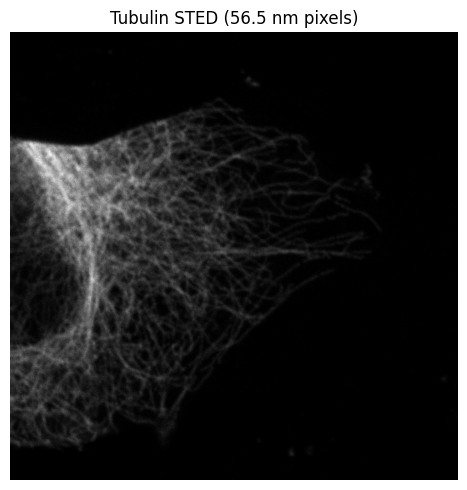

In [3]:
tubulin_rgb = io.imread("../data/Tubulin_057nm.tif")
tubulin = (color.rgb2gray(tubulin_rgb) * 255).astype(np.float32)
spacing_2d = 0.0565  # µm

if USE_GPU:
    tubulin = ascupy(tubulin)

print(
    f"Shape: {tubulin.shape}, dtype: {tubulin.dtype}, range: [{float(tubulin.min()):.1f}, {float(tubulin.max()):.1f}]"
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(asnumpy(tubulin), cmap="gray")
ax.set_title(f"Tubulin STED ({spacing_2d * 1000:.1f} nm pixels)")
ax.axis("off")
plt.tight_layout()

In [4]:
import warnings

kw = dict(spacing=spacing_2d, curve_fit_type="smooth-spline", backend="hist")

# Checkerboard (Koho et al. 2019): forward + reverse averaging (2 passes)
frc_checker = calculate_frc(tubulin, **kw)

# Binomial counts (Rieger et al. 2024): split integer photon counts
with warnings.catch_warnings():
    warnings.simplefilter(
        "ignore"
    )  # suppress non-integer warning (expected for this data)
    frc_counts = calculate_frc(
        tubulin, split_type="binomial", counts_mode="counts", rng=42, **kw
    )

# Binomial poisson_thinning: independent Poisson draws from pixel rates
frc_thinning = calculate_frc(
    tubulin, split_type="binomial", counts_mode="poisson_thinning", rng=42, **kw
)

print(
    f"Checkerboard FRC:            {frc_checker.resolution['resolution'] * 1000:.1f} nm"
)
print(
    f"Binomial counts FRC:         {frc_counts.resolution['resolution'] * 1000:.1f} nm"
)
print(
    f"Binomial poisson_thin FRC:   {frc_thinning.resolution['resolution'] * 1000:.1f} nm"
)

Checkerboard FRC:            287.8 nm
Binomial counts FRC:         332.5 nm
Binomial poisson_thin FRC:   187.3 nm


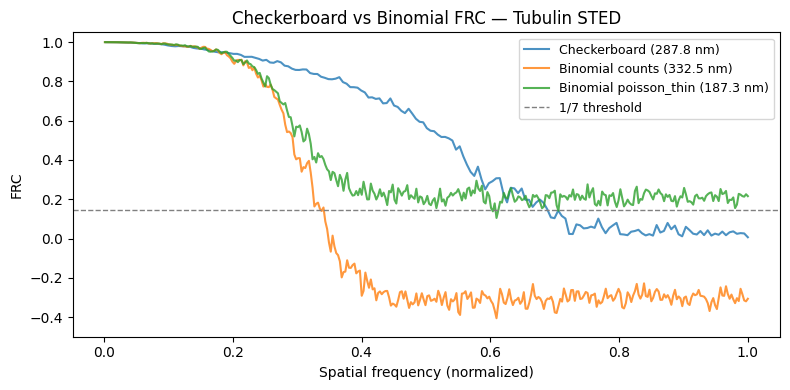

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

for label, result in [
    ("Checkerboard", frc_checker),
    ("Binomial counts", frc_counts),
    ("Binomial poisson_thin", frc_thinning),
]:
    freq = result.correlation["frequency"]
    corr = result.correlation["correlation"]
    res_nm = result.resolution["resolution"] * 1000
    ax.plot(freq, corr, label=f"{label} ({res_nm:.1f} nm)", alpha=0.8)

ax.axhline(1 / 7, color="gray", ls="--", lw=1, label="1/7 threshold")
ax.set_xlabel("Spatial frequency (normalized)")
ax.set_ylabel("FRC")
ax.set_title("Checkerboard vs Binomial FRC — Tubulin STED")
ax.legend(fontsize=9)
ax.set_ylim(-0.5, 1.05)
plt.tight_layout()

### Uncertainty quantification with multi-repeat binomial

Binomial splitting is stochastic — each run gives a slightly different FRC curve.
By setting `n_repeats > 1`, `calculate_frc` runs M independent splits and returns
the mean curve plus per-ring and per-resolution standard deviations.

Note: checkerboard splitting with `average=True` (default) already averages
forward and reverse splits (2 passes), whereas binomial with `n_repeats=1` uses
a single random split. Multi-repeat binomial provides richer uncertainty
quantification at the cost of M× computation.

Binomial FRC (10 repeats): 212.2 ± 39.2 nm


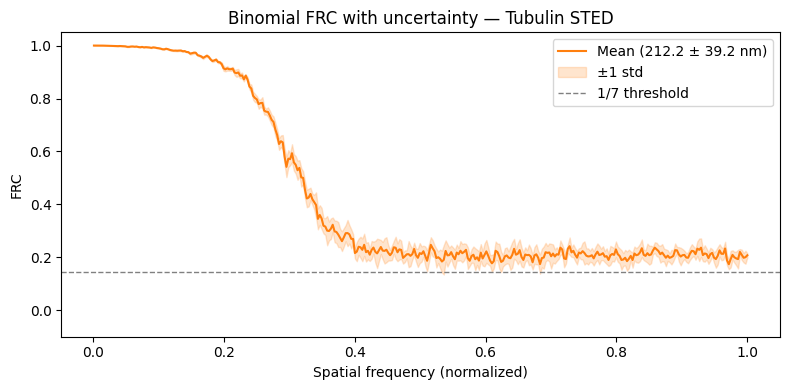

In [6]:
frc_repeat = calculate_frc(
    tubulin,
    split_type="binomial",
    counts_mode="poisson_thinning",
    n_repeats=10,
    rng=42,
    **kw,
)

freq = frc_repeat.correlation["frequency"]
mean_curve = frc_repeat.correlation["correlation"]
std_curve = frc_repeat.correlation["correlation-std"]
res = frc_repeat.resolution["resolution"] * 1000
res_std = frc_repeat.resolution["resolution-std"] * 1000

print(f"Binomial FRC (10 repeats): {res:.1f} ± {res_std:.1f} nm")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(freq, mean_curve, color="C1", label=f"Mean ({res:.1f} ± {res_std:.1f} nm)")
ax.fill_between(
    freq,
    mean_curve - std_curve,
    mean_curve + std_curve,
    color="C1",
    alpha=0.2,
    label="±1 std",
)
ax.axhline(1 / 7, color="gray", ls="--", lw=1, label="1/7 threshold")
ax.set_xlabel("Spatial frequency (normalized)")
ax.set_ylabel("FRC")
ax.set_title("Binomial FRC with uncertainty — Tubulin STED")
ax.legend()
ax.set_ylim(-0.1, 1.05)
plt.tight_layout()

## 3D FSC: Pollen Confocal

We compare directional FSC (XY and Z resolution) using checkerboard vs binomial.
The pollen volume has anisotropic spacing (250 nm Z, 77.7 nm XY), so we enable
isotropic resampling.

Since this ND2 data is not raw photon counts, we use `poisson_thinning` for the
binomial split. The checkerboard FSC should match the published reference value
of ~590 nm XY from Koho et al. 2019. The poisson_thinning result will differ —
it measures noise-model self-consistency rather than physical resolution.

ND2 dimensions: {'Z': 181, 'C': 2, 'Y': 512, 'X': 512}, dtype: uint16
Volume shape: (181, 512, 512), spacing (Z,Y,X): [0.25, 0.0777, 0.0777] µm


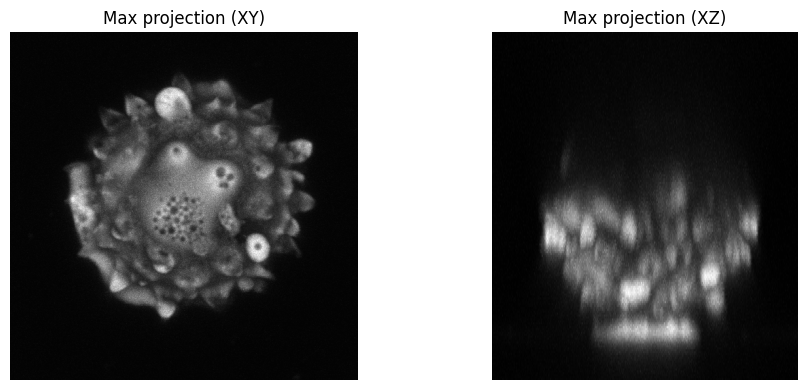

In [7]:
try:
    import nd2
except ImportError:
    raise ImportError(
        "nd2 library required for this section. Install with: pip install nd2"
    )

spacing_3d = [0.250, 0.0777, 0.0777]  # Z, Y, X in µm

with nd2.ND2File("../data/40x_TAGoff_z_galvo.nd2") as f:
    volume = f.asarray()
    print(f"ND2 dimensions: {f.sizes}, dtype: {volume.dtype}")
    dim_order = list(f.sizes.keys())
    c_axis = dim_order.index("C")
    volume = np.take(volume, 0, axis=c_axis).astype(np.float32)

if USE_GPU:
    volume = ascupy(volume)

print(f"Volume shape: {volume.shape}, spacing (Z,Y,X): {spacing_3d} µm")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vol_np = asnumpy(volume)
axes[0].imshow(vol_np.max(axis=0), cmap="gray")
axes[0].set_title("Max projection (XY)")
axes[1].imshow(vol_np.max(axis=1), cmap="gray", aspect=spacing_3d[0] / spacing_3d[2])
axes[1].set_title("Max projection (XZ)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

In [8]:
fsc_kw = dict(
    spacing=spacing_3d,
    resample_isotropic=True,
    angle_delta=15,
    resolution_threshold="one-bit",
    backend="hist",
)

# Checkerboard FSC
fsc_checker = fsc_resolution(volume, **fsc_kw)
print(
    f"Checkerboard FSC — XY: {fsc_checker['xy'] * 1000:.1f} nm, Z: {fsc_checker['z'] * 1000:.1f} nm"
)

# Binomial FSC
fsc_binom = fsc_resolution(
    volume, split_type="binomial", counts_mode="poisson_thinning", rng=42, **fsc_kw
)
print(
    f"Binomial FSC     — XY: {fsc_binom['xy'] * 1000:.1f} nm, Z: {fsc_binom['z'] * 1000:.1f} nm"
)

Checkerboard FSC — XY: 583.6 nm, Z: 4363.1 nm
Binomial FSC     — XY: 187.2 nm, Z: 697.7 nm


In [ ]:
# Binomial FSC with uncertainty (5 repeats)
fsc_repeat = fsc_resolution(
    volume,
    split_type="binomial",
    counts_mode="poisson_thinning",
    n_repeats=5,
    rng=42,
    **fsc_kw,
)

print(f"Binomial FSC (5 repeats):")
print(f"  XY: {fsc_repeat['xy'] * 1000:.1f} ± {fsc_repeat['xy_std'] * 1000:.1f} nm")
print(f"  Z:  {fsc_repeat['z'] * 1000:.1f} ± {fsc_repeat['z_std'] * 1000:.1f} nm")

## Summary

**Why do the results differ?**

- **Checkerboard vs binomial counts (~10–15% gap):** Checkerboard operates on
  half-size images with a diagonal subsampling calibration correction (Koho et al.
  2019 Supplementary Note 1). Binomial counts preserves full image size with no
  calibration needed. The ~10–15% difference is expected from these methodological
  differences. Checkerboard results match the Koho et al. published reference values.

- **Poisson thinning vs checkerboard (large gap):** `poisson_thinning` draws two
  independent Poisson samples from the pixel intensity — it measures the
  reproducible bandwidth of a Poisson noise model, not the physical resolution of
  the imaging system. For high-signal images the FRC stays high at all frequencies,
  giving an optimistically low resolution estimate. This is a fundamentally
  different quantity from checkerboard or binomial-counts FRC.

**When to use each method:**

- **Checkerboard** (default): Works on any image, no calibration needed.
  Best for compatibility with existing FRC/FSC workflows and published reference values.
- **Binomial + counts**: For raw camera data with known gain/offset/readout noise.
  Preserves full image size and avoids subsampling artifacts.
- **Binomial + poisson_thinning**: Fallback for processed/deconvolved images.
  Measures self-consistency of the noise model, not physical resolution.